# Day 29: Understanding Model Bias and Variance

---
## 🔹 Learning Objectives:
Understand the concept of bias and variance in machine learning.
Study learning curves to diagnose underfitting & overfitting.
Practice on a real-world dataset with robust visualizations.

---
    
### 1. What is Bias-Variance Tradeoff? 🤔
Machine Learning models make predictions based on patterns in data. However, models can fail due to two key issues:<br>
Concept	Definition	Effect on Model<br>
Bias (Underfitting)	Model is too simple and does not learn the patterns well.High training & testing error.<br>
Variance (Overfitting)	Model is too complex and memorizes training data.	Low training error, high testing error.<br>

#### Key Idea:
- **High Bias**: Model is too simple → Misses patterns (Underfitting).
- **High Variance**: Model is too complex → Memorizes noise (Overfitting).
- **Goal**: Find the balance between bias and variance for good generalization.

### 🚀 Solution?
- Use learning curves to diagnose the problem.
- Apply regularization techniques (like Ridge/Lasso regression).
- Use cross-validation for better model tuning.

---


### 2. Dataset: Boston Housing Prices

---

In [28]:
#Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import Ridge

In [5]:
# Load the Dataset
data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)

In [6]:
#Display first few rows
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [7]:
#Statistical Summary
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


In [8]:
#Missing values
df.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64

In [9]:
#Set Target variable
df['Price'] = data.target

### 3. Visualizing the Dataset

---
Check How fetures relate to house prices

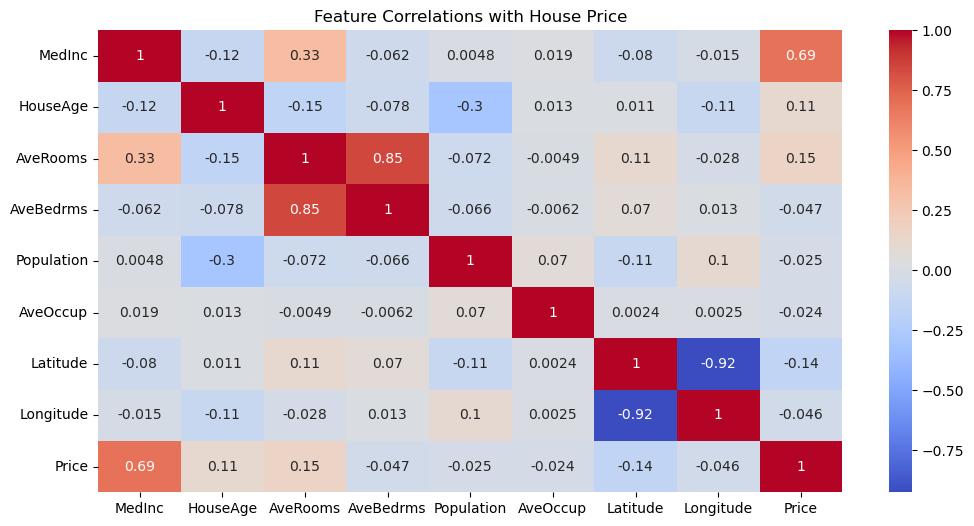

In [10]:
plt.figure(figsize=(12,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlations with House Price')
plt.show()

##### Insight: Some features like **MedInc (Median Income)** are ***strongly*** correlated with house prices.

### 4. Model Comparison: High Bias vs High Variance

---
Let's compare Linear Regression (High Bias) vs Decision Tree (High Variance).

In [11]:
#Train Models
X = df.drop(columns=['Price'])
y = df['Price']
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [12]:
#Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [16]:
#Train the model
lr = LinearRegression()
dt = DecisionTreeRegressor(max_depth=10)

In [17]:
lr.fit(X_train_scaled, y_train)
dt.fit(X_train_scaled, y_train)

DecisionTreeRegressor(max_depth=10)

In [18]:
#Predictions
y_pred_lr = lr.predict(X_test_scaled)
y_pred_dt = dt.predict(X_test_scaled)

In [19]:
#Compute Errors
mse_lr = mean_squared_error(y_test, y_pred_lr)
mse_dt = mean_squared_error(y_test, y_pred_lr)

In [20]:
print(f'Linear Regression MSE: {mse_lr:.4f} (High Bias)')
print(f'Decision Tree MSE: {mse_dt:.4f} (High Variance)')

Linear Regression MSE: 0.5559 (High Bias)
Decision Tree MSE: 0.5559 (High Variance)


### 5. Learning Curves: Diagnosing Bias and Variance

---
Plotting the Learning Curve to see underfitting and overfitting

In [26]:
def plot_learning_curve(model, X, y, title):
    train_sizes, train_scores, test_scores = learning_curve(model, 
                                                            X, 
                                                            y,
                                                            cv=5,
                                                            scoring='neg_mean_squared_error', 
                                                            train_sizes=np.linspace(0.1,1.0, 10))
    train_scores_mean = -train_scores.mean(axis=1)
    test_scores_mean = -test_scores.mean(axis=1)

    plt.figure(figsize=(8,5))
    plt.plot(train_sizes, train_scores_mean, 'o-', color='blue', label='Training Error')
    plt.plot(train_sizes, test_scores_mean, 'o-', color='red', label='Validation Error')
    plt.xlabel('Training Size')
    plt.ylabel('MSE')
    plt.title(title)
    plt.legend()
    plt.show()

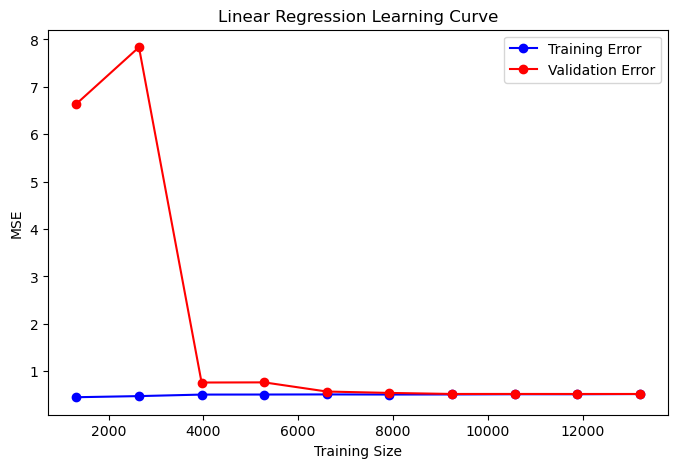

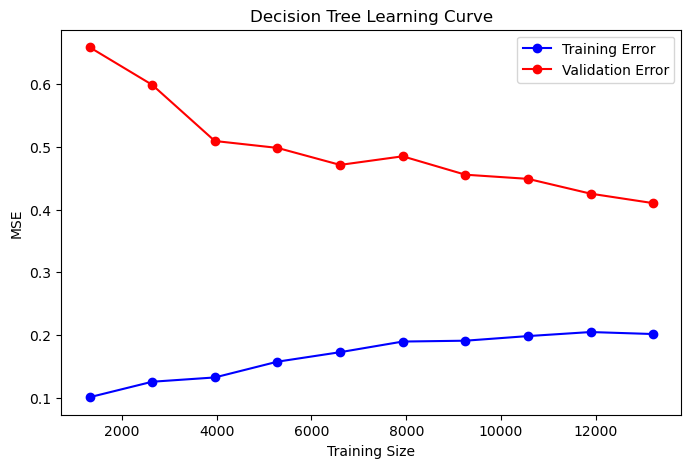

In [27]:
plot_learning_curve(lr, X_train_scaled, y_train, 'Linear Regression Learning Curve')
plot_learning_curve(dt, X_train_scaled, y_train, 'Decision Tree Learning Curve')

### 6. Understanding Results

---

**Linear Regression (High Bias)**
- Training & test errors are both high → The model is too simple.
- Underfitting occurs (Model does not capture data well).

**Decision Tree (High Variance)**
- Training error is very low, but test error is high → The model memorizes training data.
- Overfitting occurs (Model fails to generalize to new data).

### 7. Solution: Regularization

---
We apply Ridge Regression (L2 regularization) to reduce overfitting.

In [29]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

Ridge()

In [31]:
y_pred_ridge = ridge.predict(X_test_scaled)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)

print(f'Ride Regression MSE: {mse_ridge:.4f} (Balanced Model)')

Ride Regression MSE: 0.5559 (Balanced Model)


### 8. Key Takeaways

---
✅High Bias (Underfitting)<br>
Happens when the model is too simple.<br>
Solution: Use more complex models or add features.<br>
✅ High Variance (Overfitting)<br>
Happens when the model memorizes training data.<br>
Solution: Use regularization (Ridge/Lasso) or reduce model complexity.<br>
✅ Best Practice<br>
Diagnose Bias-Variance using learning curves.<br>
Find the right balance between model complexity & generalization.<br>
